# 🛵 Last-Mile Delivery Performance & Delay Analysis

**Role:** Operations Analyst · **Tools:** Python (Pandas, NumPy, Matplotlib/Seaborn) → Tableau Public

**Business problem:** Delivery times have surged and customer complaints are up. Is the bottleneck
**kitchen prep delays**, **traffic / transit time**, or **peak hours**?

**Notebook outline**
1. Load & inspect raw data
2. Data cleaning (types, timestamps, missing & invalid values)
3. Outlier removal
4. Feature engineering (Prep / Transit / Total time, time-of-day, delay flag)
5. Export clean dataset for Tableau
6. Exploratory analysis → key findings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
os.makedirs("images", exist_ok=True)

DATA_PATH = "train.csv"            # raw Kaggle file
OUT_PATH  = "clean_delivery_data.csv"
SLA_MINUTES = 30                   # business rule: order is 'Delayed' if total time > 30 min

## 1. Load & inspect raw data

In [2]:
raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
raw.head()

Shape: (45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

**Observations on the raw file**
- Text columns carry trailing spaces (`'High '`, `'Snack '`) and the literal string `'NaN'` instead of real nulls.
- `Time_taken(min)` is stored as text like `"(min) 24"`; `Weatherconditions` as `"conditions Sunny"`.
- Dates are `dd-mm-yyyy` strings; times are `HH:MM:SS` strings with **no date attached** (matters for orders after midnight).
- There is **no delivery timestamp** — only *order time*, *pickup time* and *total time taken*. So:
  - Prep Time = pickup − order
  - Total Delivery Time = `Time_taken(min)`
  - Transit Time = Total − Prep

## 2. Data cleaning

### 2.1 Standardise text & convert placeholders to real nulls

In [4]:
df = raw.copy()

# strip whitespace on every text column, turn the string 'NaN' into a real NaN
obj_cols = df.select_dtypes(exclude="number").columns
for c in obj_cols:
    df[c] = df[c].astype("string").str.strip()
df = df.replace("NaN", np.nan)

# tidy column names / values
df = df.rename(columns={"Time_Orderd": "Time_Ordered", "Time_taken(min)": "Time_taken_raw"})
df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "", regex=False)
df["City"] = df["City"].replace({"Metropolitian": "Metropolitan"})   # fix spelling

# numeric conversions
df["Delivery_person_Age"]     = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")
df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")
df["multiple_deliveries"]     = pd.to_numeric(df["multiple_deliveries"], errors="coerce")
df["Total_Delivery_Time"]     = df["Time_taken_raw"].str.extract(r"(\d+)")[0].astype(float)

# city (from delivery-person ID prefix, e.g. INDORES13DEL02 -> INDO)
df["City_Code"] = df["Delivery_person_ID"].str.extract(r"^([A-Z]+?)RES")[0]

print("Missing values (%):")
(df.isna().mean().mul(100).round(2).loc[lambda s: s > 0]).sort_values(ascending=False)

Missing values (%):


Delivery_person_Ratings    4.18
Delivery_person_Age        4.07
Time_Ordered               3.80
City                       2.63
multiple_deliveries        2.18
Road_traffic_density       1.32
Festival                   0.50
dtype: float64

### 2.2 Timestamps
Order date + order time / pickup time are combined into real datetimes.
Where the pickup clock time is *earlier* than the order clock time, the order crossed midnight
(e.g. ordered 23:50, picked up 00:05) → we add one day rather than treating it as an error.

In [5]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y", errors="coerce")

ordered_t = pd.to_datetime(df["Time_Ordered"],      format="%H:%M:%S", errors="coerce")
picked_t  = pd.to_datetime(df["Time_Order_picked"], format="%H:%M:%S", errors="coerce")

prep = (picked_t - ordered_t).dt.total_seconds() / 60
n_midnight = (prep < 0).sum()
prep = prep.where(prep >= 0, prep + 24 * 60)          # midnight crossover fix
print(f"Orders crossing midnight fixed: {n_midnight}")

df["Ordered_At"] = df["Order_Date"] + (ordered_t - ordered_t.dt.normalize())
df["Picked_At"]  = df["Ordered_At"] + pd.to_timedelta(prep, unit="m")
df["Prep_Time"]  = prep
df[["Order_Date","Ordered_At","Picked_At","Prep_Time","Total_Delivery_Time"]].head()

Orders crossing midnight fixed: 831


,Order_Date,Ordered_At,Picked_At,Prep_Time,Total_Delivery_Time
0,2022-03-19,2022-03-19 11:30:00,2022-03-19 11:45:00,15.0,24.0
1,2022-03-25,2022-03-25 19:45:00,2022-03-25 19:50:00,5.0,33.0
2,2022-03-19,2022-03-19 08:30:00,2022-03-19 08:45:00,15.0,26.0
3,2022-04-05,2022-04-05 18:00:00,2022-04-05 18:10:00,10.0,21.0
4,2022-03-26,2022-03-26 13:30:00,2022-03-26 13:45:00,15.0,30.0


### 2.3 Missing values
| Column | Strategy | Why |
|---|---|---|
| `Time_Ordered` | **drop row** | Prep time, transit time and hour-of-day cannot be computed — imputing would fabricate the core metric |
| `Delivery_person_Age`, `Ratings` | median | Numeric, low share, not central to the question |
| `multiple_deliveries` | mode | Discrete count |
| `Weather`, `Traffic`, `Festival`, `City` | `'Unknown'` | Keep the rows, but make the gap visible in the dashboard |

In [6]:
n0 = len(df)
df = df.dropna(subset=["Time_Ordered"]).copy()
print(f"Dropped {n0-len(df):,} rows with no order time ({(n0-len(df))/n0:.1%})")

df["Delivery_person_Age"]     = df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())
df["multiple_deliveries"]     = df["multiple_deliveries"].fillna(df["multiple_deliveries"].mode()[0])
for c in ["Weatherconditions", "Road_traffic_density", "Festival", "City"]:
    df[c] = df[c].fillna("Unknown")

df.isna().sum().loc[lambda s: s > 0]

Dropped 1,731 rows with no order time (3.8%)


Series([], dtype: int64)

### 2.4 Invalid values

In [7]:
before = len(df)

# (a) Ratings are on a 1–5 scale -> anything above 5 is invalid
bad_rating = df["Delivery_person_Ratings"] > 5
# (b) Couriers must be adults
bad_age = df["Delivery_person_Age"] < 18
print("Ratings > 5:", bad_rating.sum(), "| Age < 18:", bad_age.sum())
df = df[~bad_rating & ~bad_age].copy()

# (c) Coordinates: a sign-flipped restaurant lat/lon is fixed with abs();
#     (0, 0) restaurant + ~(0.01, 0.01) drop-off are placeholder coordinates -> distance unknown
placeholder = (df["Restaurant_latitude"] == 0) & (df["Restaurant_longitude"] == 0)
print("Placeholder (0,0) coordinate rows:", placeholder.sum())
df[["Restaurant_latitude", "Restaurant_longitude"]] = df[["Restaurant_latitude", "Restaurant_longitude"]].abs()
for c in ["Restaurant_latitude","Restaurant_longitude","Delivery_location_latitude","Delivery_location_longitude"]:
    df.loc[placeholder, c] = np.nan

# (d) Logical check: total time must be longer than prep time, otherwise transit <= 0
df["Transit_Time"] = df["Total_Delivery_Time"] - df["Prep_Time"]
bad_transit = df["Transit_Time"] <= 0
print("Total time <= prep time (impossible):", bad_transit.sum())
df = df[~bad_transit].copy()

print(f"Removed {before-len(df):,} invalid rows -> {len(df):,} remain")

Ratings > 5: 0 | Age < 18: 0
Placeholder (0,0) coordinate rows: 3509
Total time <= prep time (impossible): 2054
Removed 2,054 invalid rows -> 41,808 remain


## 3. Outlier removal
IQR rule (1.5 × IQR) applied to **Total Delivery Time** and **Transit Time**.
Prep time only takes three values (5/10/15 min) so it has no outliers.

In [8]:
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

before = len(df)
mask = pd.Series(True, index=df.index)
for col in ["Total_Delivery_Time", "Transit_Time"]:
    lo, hi = iqr_bounds(df[col])
    print(f"{col}: keep [{lo:.1f}, {hi:.1f}]")
    mask &= df[col].between(lo, hi)

df = df[mask].copy()
print(f"Outliers removed: {before-len(df):,} ({(before-len(df))/before:.2%})")

Total_Delivery_Time: keep [0.5, 52.5]
Transit_Time: keep [-9.5, 42.5]
Outliers removed: 436 (1.04%)


## 4. Feature engineering
- **Prep_Time**, **Transit_Time**, **Total_Delivery_Time** (minutes)
- **Distance_km** — haversine distance restaurant → customer
- **Order_Hour**, **Day_of_Week**, **Is_Weekend**
- **Time_of_Day** category and **Is_Peak**
- **Is_Delayed** flag (total > SLA) and **Delay_Minutes**
- **Prep_Share_%** — share of total time spent in the kitchen (the bottleneck metric)

In [9]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dl = p2 - p1, np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["Distance_km"] = haversine(df["Restaurant_latitude"], df["Restaurant_longitude"],
                              df["Delivery_location_latitude"], df["Delivery_location_longitude"]).round(2)

df["Order_Hour"]  = df["Ordered_At"].dt.hour
df["Day_of_Week"] = df["Ordered_At"].dt.day_name()
df["Is_Weekend"]  = df["Ordered_At"].dt.dayofweek >= 5

def time_of_day(h):
    if   6 <= h < 12:  return "Morning Rush"
    elif 12 <= h < 15: return "Lunch"
    elif 15 <= h < 17: return "Afternoon Lull"
    elif 17 <= h < 21: return "Dinner Rush"
    else:              return "Late Night"

df["Time_of_Day"] = df["Order_Hour"].apply(time_of_day)
df["Is_Peak"]     = df["Time_of_Day"].isin(["Morning Rush", "Dinner Rush"])

df["Is_Delayed"]    = df["Total_Delivery_Time"] > SLA_MINUTES
df["Delay_Minutes"] = (df["Total_Delivery_Time"] - SLA_MINUTES).clip(lower=0)
df["Prep_Share_%"]  = (df["Prep_Time"] / df["Total_Delivery_Time"] * 100).round(1)

df[["Prep_Time","Transit_Time","Total_Delivery_Time","Distance_km","Time_of_Day","Is_Delayed"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Prep_Time,41372.0,NaN,NaN,NaN,9.803611,4.044002,5.0,5.0,10.0,15.0,15.0
Transit_Time,41372.0,NaN,NaN,NaN,16.910495,9.298619,1.0,10.0,16.0,23.0,42.0
Total_Delivery_Time,41372.0,NaN,NaN,NaN,26.714106,8.773096,10.0,20.0,26.0,33.0,52.0
Distance_km,38078.0,NaN,NaN,NaN,9.796204,5.59303,1.47,4.66,9.22,13.68,20.97
Time_of_Day,41372,5,Dinner Rush,17163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Delayed,41372,2,False,28724,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("Orders per time-of-day:")
print(df["Order_Hour"].value_counts().sort_index().to_dict())
print(f"\nDelayed orders (> {SLA_MINUTES} min): {df['Is_Delayed'].mean():.1%}")

Orders per time-of-day:
{0: 395, 8: 1632, 9: 1747, 10: 1800, 11: 1863, 12: 838, 13: 759, 14: 761, 15: 827, 16: 670, 17: 4133, 18: 4326, 19: 4390, 20: 4314, 21: 4448, 22: 4274, 23: 4195}

Delayed orders (> 30 min): 30.6%


## 5. Export clean dataset

In [11]:
final_cols = [
    "ID", "Delivery_person_ID", "City_Code", "City", "Delivery_person_Age", "Delivery_person_Ratings",
    "Order_Date", "Ordered_At", "Picked_At", "Order_Hour", "Day_of_Week", "Is_Weekend",
    "Time_of_Day", "Is_Peak",
    "Prep_Time", "Transit_Time", "Total_Delivery_Time", "Prep_Share_%",
    "Is_Delayed", "Delay_Minutes",
    "Distance_km", "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
    "Type_of_vehicle", "Vehicle_condition", "Type_of_order", "multiple_deliveries",
    "Weatherconditions", "Road_traffic_density", "Festival",
]
clean = df[final_cols].rename(columns={
    "Delivery_person_Age": "Courier_Age", "Delivery_person_Ratings": "Courier_Rating",
    "Type_of_vehicle": "Vehicle_Type", "Type_of_order": "Order_Type",
    "multiple_deliveries": "Multiple_Deliveries", "Weatherconditions": "Weather",
    "Road_traffic_density": "Traffic_Density", "Vehicle_condition": "Vehicle_Condition",
    "City": "City_Type", "City_Code": "City",
}).reset_index(drop=True)

clean["Is_Delayed"] = clean["Is_Delayed"].map({True: "Delayed", False: "On Time"})   # friendlier in Tableau
clean["Is_Peak"]    = clean["Is_Peak"].map({True: "Peak", False: "Off-Peak"})
clean.to_csv(OUT_PATH, index=False)
print(f"Saved {OUT_PATH}: {clean.shape[0]:,} rows x {clean.shape[1]} columns")
print(f"Rows kept from raw: {len(clean)/len(raw):.1%}")
clean.head()

Saved clean_delivery_data.csv: 41,372 rows x 32 columns
Rows kept from raw: 90.7%


,ID,Delivery_person_ID,City,City_Type,Courier_Age,Courier_Rating,Order_Date,Ordered_At,Picked_At,Order_Hour,Day_of_Week,Is_Weekend,Time_of_Day,Is_Peak,Prep_Time,Transit_Time,Total_Delivery_Time,Prep_Share_%,Is_Delayed,Delay_Minutes,Distance_km,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_Type,Vehicle_Condition,Order_Type,Multiple_Deliveries,Weather,Traffic_Density,Festival
0,0x4607,INDORES13DEL02,INDO,Urban,37,4.9,2022-03-19,2022-03-19 11:30:00,2022-03-19 11:45:00,11,Saturday,True,Morning Rush,Peak,15.0,9.0,24.0,62.5,On Time,0.0,3.03,22.745049,75.892471,22.765049,75.912471,motorcycle,2,Snack,0,Sunny,High,No
1,0xb379,BANGRES18DEL02,BANG,Metropolitan,34,4.5,2022-03-25,2022-03-25 19:45:00,2022-03-25 19:50:00,19,Friday,False,Dinner Rush,Peak,5.0,28.0,33.0,15.2,Delayed,3.0,20.18,12.913041,77.683237,13.043041,77.813237,scooter,2,Snack,1,Stormy,Jam,No
2,0x5d6d,BANGRES19DEL01,BANG,Urban,23,4.4,2022-03-19,2022-03-19 08:30:00,2022-03-19 08:45:00,8,Saturday,True,Morning Rush,Peak,15.0,11.0,26.0,57.7,On Time,0.0,1.55,12.914264,77.678400,12.924264,77.688400,motorcycle,0,Drinks,1,Sandstorms,Low,No
3,0x7a6a,COIMBRES13DEL02,COIMB,Metropolitan,38,4.7,2022-04-05,2022-04-05 18:00:00,2022-04-05 18:10:00,18,Tuesday,False,Dinner Rush,Peak,10.0,11.0,21.0,47.6,On Time,0.0,7.79,11.003669,76.976494,11.053669,77.026494,motorcycle,0,Buffet,1,Sunny,Medium,No
4,0x70a2,CHENRES12DEL01,CHEN,Metropolitan,32,4.6,2022-03-26,2022-03-26 13:30:00,2022-03-26 13:45:00,13,Saturday,True,Lunch,Off-Peak,15.0,15.0,30.0,50.0,On Time,0.0,6.21,12.972793,80.249982,13.012793,80.289982,scooter,1,Snack,1,Cloudy,High,No


## 6. Exploratory analysis — where is the bottleneck?

### 6.1 Prep vs Transit: which stage takes the time?

Prep_Time        9.8
Transit_Time    16.9
dtype: float64

Transit = 63% of average delivery time, Prep = 37%


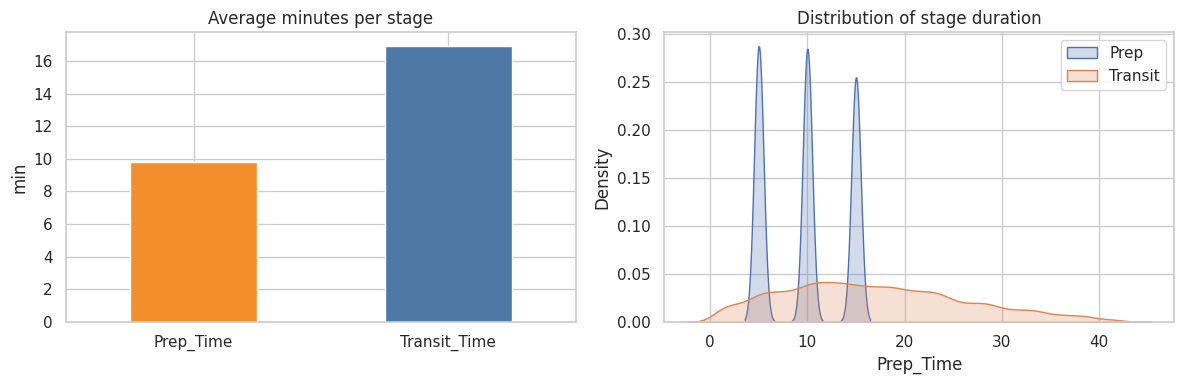

In [12]:
stage = clean[["Prep_Time", "Transit_Time"]].mean()
print(stage.round(1))
print(f"\nTransit = {stage['Transit_Time']/stage.sum():.0%} of average delivery time, Prep = {stage['Prep_Time']/stage.sum():.0%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
stage.plot.bar(ax=ax[0], color=["#F28E2B", "#4E79A7"]); ax[0].set_title("Average minutes per stage"); ax[0].set_ylabel("min"); ax[0].tick_params(axis="x", rotation=0)
sns.kdeplot(data=clean, x="Prep_Time", label="Prep", ax=ax[1], fill=True)
sns.kdeplot(data=clean, x="Transit_Time", label="Transit", ax=ax[1], fill=True)
ax[1].set_title("Distribution of stage duration"); ax[1].legend()
plt.tight_layout(); plt.savefig("images/01_prep_vs_transit.png", dpi=150); plt.show()

### 6.2 Which stage explains *delays*? (delayed vs on-time orders)

In [13]:
by_status = clean.groupby("Is_Delayed")[["Prep_Time", "Transit_Time", "Total_Delivery_Time"]].mean().round(1)
display(by_status)
gap = by_status.loc["Delayed"] - by_status.loc["On Time"]
print("Extra minutes on delayed orders:\n", gap.round(1))
print("\nCorrelation with Total_Delivery_Time:")
print(clean[["Prep_Time", "Transit_Time", "Distance_km"]].corrwith(clean["Total_Delivery_Time"]).round(2))

,Prep_Time,Transit_Time,Total_Delivery_Time
Is_Delayed,,,
Delayed,10.1,27.4,37.5
On Time,9.7,12.3,22.0


Extra minutes on delayed orders:
 Prep_Time               0.4
Transit_Time           15.1
Total_Delivery_Time    15.5
dtype: float64

Correlation with Total_Delivery_Time:
Prep_Time       0.10
Transit_Time    0.90
Distance_km     0.31
dtype: float64


### 6.3 Peak-hour bottlenecks

,Orders,Prep,Transit,Total,Delay_Rate
Time_of_Day,,,,,
Morning Rush,7042,9.5,12.5,22.1,10.0
Lunch,2358,9.8,17.6,27.5,33.9
Afternoon Lull,1497,9.7,14.0,23.7,16.2
Dinner Rush,17163,9.9,19.4,29.3,43.3
Late Night,13312,9.8,16.2,26.0,26.1


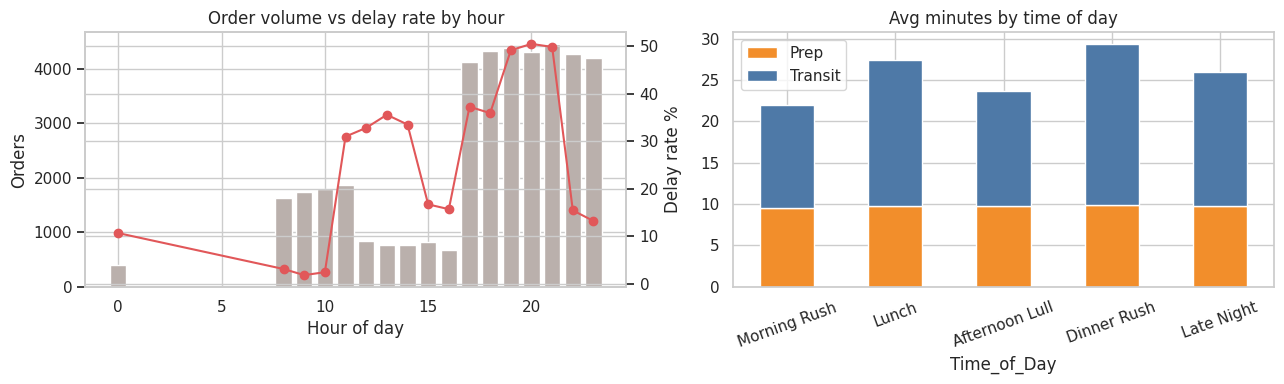

In [14]:
order = ["Morning Rush", "Lunch", "Afternoon Lull", "Dinner Rush", "Late Night"]
tod = clean.groupby("Time_of_Day").agg(Orders=("ID", "count"),
                                       Prep=("Prep_Time", "mean"),
                                       Transit=("Transit_Time", "mean"),
                                       Total=("Total_Delivery_Time", "mean"),
                                       Delay_Rate=("Is_Delayed", lambda s: (s == "Delayed").mean() * 100)).reindex(order).round(1)
display(tod)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hourly = clean.groupby("Order_Hour").agg(Orders=("ID", "count"), Delay_Rate=("Is_Delayed", lambda s: (s == "Delayed").mean() * 100))
ax[0].bar(hourly.index, hourly["Orders"], color="#BAB0AC"); ax[0].set_ylabel("Orders"); ax[0].set_xlabel("Hour of day")
ax2 = ax[0].twinx(); ax2.plot(hourly.index, hourly["Delay_Rate"], color="#E15759", marker="o"); ax2.set_ylabel("Delay rate %")
ax[0].set_title("Order volume vs delay rate by hour")
tod[["Prep", "Transit"]].plot.bar(stacked=True, ax=ax[1], color=["#F28E2B", "#4E79A7"]); ax[1].set_title("Avg minutes by time of day"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig("images/02_peak_hours.png", dpi=150); plt.show()

### 6.4 Traffic, weather, vehicle and city hotspots

In [15]:
def delay_table(col):
    return (clean.groupby(col).agg(Orders=("ID", "count"),
                                   Avg_Total=("Total_Delivery_Time", "mean"),
                                   Delay_Rate=("Is_Delayed", lambda s: (s == "Delayed").mean() * 100))
                 .round(1).sort_values("Delay_Rate", ascending=False))

for col in ["Traffic_Density", "Weather", "Vehicle_Type", "City_Type", "Multiple_Deliveries", "Festival"]:
    print(f"--- {col} ---"); display(delay_table(col))

--- Traffic_Density ---


,Orders,Avg_Total,Delay_Rate
Traffic_Density,,,
Jam,13122,31.0,50.4
High,4131,27.5,33.9
Medium,10285,27.2,33.6
Low,13834,22.1,8.6


--- Weather ---


,Orders,Avg_Total,Delay_Rate
Weather,,,
Cloudy,6969,29.3,44.8
Fog,7143,29.1,44.5
Windy,6863,26.5,27.1
Sandstorms,6922,26.3,26.6
Stormy,7031,26.2,26.0
Sunny,6444,22.5,12.8


--- Vehicle_Type ---


...

,Orders,Avg_Total,Delay_Rate
City_Type,,,
Semi-Urban,93,48.2,100.0
Metropolitan,31404,27.6,33.8
Urban,8846,23.9,20.1
Unknown,1029,23.0,16.9


--- Multiple_Deliveries ---


,Orders,Avg_Total,Delay_Rate
Multiple_Deliveries,,,
3,241,46.3,100.0
2,1840,40.0,100.0
1,26970,27.0,30.3
0,12321,23.8,19.5


--- Festival ---


,Orders,Avg_Total,Delay_Rate
Festival,,,
Yes,719,44.4,100.0
No,40547,26.4,29.4
Unknown,106,11.5,0.0


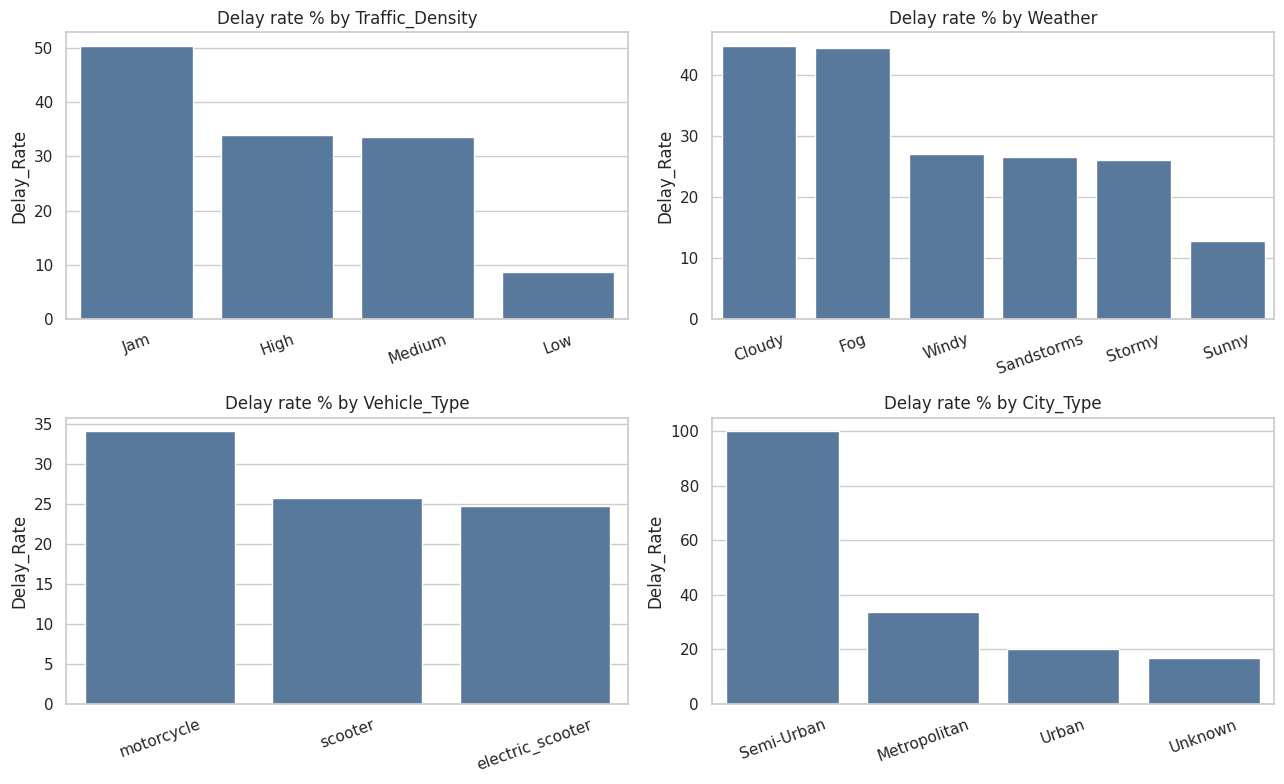

In [16]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for a, col in zip(ax.ravel(), ["Traffic_Density", "Weather", "Vehicle_Type", "City_Type"]):
    t = delay_table(col)
    sns.barplot(x=t.index, y=t["Delay_Rate"], ax=a, color="#4E79A7"); a.set_title(f"Delay rate % by {col}"); a.set_xlabel(""); a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig("images/03_delay_drivers.png", dpi=150); plt.show()

In [17]:
top_cities = clean.groupby("City").agg(Orders=("ID","count"), Avg_Total=("Total_Delivery_Time","mean"),
                                        Delay_Rate=("Is_Delayed", lambda s: (s=="Delayed").mean()*100)).round(1).sort_values("Delay_Rate", ascending=False)
top_cities.head(8)

,Orders,Avg_Total,Delay_Rate
City,,,
DEH,662,27.2,33.8
ALH,668,27.4,33.4
AURG,638,27.1,32.6
JAP,3144,27.1,32.5
BHP,636,27.2,32.4
LUDH,693,26.7,32.3
AGR,707,27.1,32.0
HYD,2882,26.9,31.5


### 6.5 Interaction: traffic × time of day

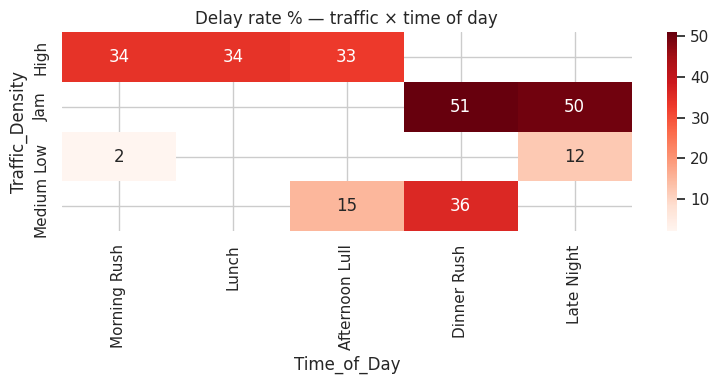

In [18]:
pivot = clean.pivot_table(index="Traffic_Density", columns="Time_of_Day", values="Is_Delayed",
                          aggfunc=lambda s: (s == "Delayed").mean() * 100)[order]
plt.figure(figsize=(8, 4)); sns.heatmap(pivot.round(0), annot=True, fmt=".0f", cmap="Reds"); plt.title("Delay rate % — traffic × time of day")
plt.tight_layout(); plt.savefig("images/04_heatmap.png", dpi=150); plt.show()

## 7. Key findings
*(Fill in with the numbers from the cells above — see the README for the wording used.)*

In [19]:
prep_avg, transit_avg = stage["Prep_Time"], stage["Transit_Time"]
worst_traffic = delay_table("Traffic_Density").iloc[0]
best_traffic  = delay_table("Traffic_Density").iloc[-1]
print(f"1. Transit is {transit_avg/(prep_avg+transit_avg):.0%} of delivery time; prep only {prep_avg/(prep_avg+transit_avg):.0%}.")
print(f"2. Delayed orders spend {gap['Transit_Time']:.1f} more min in transit but only {gap['Prep_Time']:.1f} more min in the kitchen.")
print(f"3. Delay rate: {worst_traffic.name} traffic {worst_traffic['Delay_Rate']:.0f}% vs {best_traffic.name} {best_traffic['Delay_Rate']:.0f}%.")
print(f"4. Busiest window: {tod['Orders'].idxmax()} ({tod['Orders'].max():,} orders) with a {tod.loc[tod['Orders'].idxmax(), 'Delay_Rate']:.0f}% delay rate.")

1. Transit is 63% of delivery time; prep only 37%.
2. Delayed orders spend 15.1 more min in transit but only 0.4 more min in the kitchen.
3. Delay rate: Jam traffic 50% vs Low 9%.
4. Busiest window: Dinner Rush (17,163 orders) with a 43% delay rate.
